# Transformación de datos y regresión: reserva automática y ocupación por ciudad

**Sprint 2 — Data Transformation / Análisis por pregunta de negocio (Operaciones y gestión de inventario)**

**Pregunta de negocio:** ¿qué repercusión tiene la opción de reserva
automática (`is_instant_bookable`) en la ocupación media de cada ciudad?

Este notebook parte del dataset bruto y realiza todo el proceso
necesario para responder a la pregunta anterior:

1. Construcción de las variables de ocupación para los distintos
   plazos disponibles (30, 60, 90 y 365 días).
2. Exploración inicial de los datos (EDA).
3. Revisión de multicolinealidad entre variables explicativas (VIF).
4. Reducción de datos: se eliminan las columnas que no se usan en
   este análisis.
5. Modelo de regresión lineal múltiple y verificación de sus
   supuestos.
6. Comprobación de robustez del modelo en los distintos plazos.

**Puntos clave del enfoque:**
- Se trabaja con la **ocupación en días** (no en porcentaje), porque
  la variable dependiente de una regresión lineal debe ser numérica
  y continua, y expresarla en días es la forma más directa de
  interpretarla.
- Se revisa con cuidado la posible **multicolinealidad** entre
  `bedrooms` (número de habitaciones), `room_type` (tipo de
  alojamiento) y `accommodates` (capacidad), antes de dar por
  buenos los coeficientes del modelo.

El análisis avanza **de lo general a lo particular**: primero una
foto agregada de la ocupación por ciudad y por reserva automática,
después la revisión de colinealidad entre variables explicativas, y
por último el modelo de regresión múltiple con su verificación de
supuestos.

## 1. Librerías

Instalamos `statsmodels`, ya que no viene incluida por defecto en
todos los entornos y la necesitamos para el modelo de regresión y
para el cálculo del VIF.

In [1]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Importamos el resto de librerías que se usarán a lo largo del
notebook:

- `pandas` y `numpy`: carga y manipulación de datos.
- `matplotlib` y `seaborn`: gráficos.
- `statsmodels`: modelo de regresión, VIF y test de normalidad.
- `patsy`: construcción de la matriz de diseño (variables dummy)
  para el cálculo del VIF.
- `pathlib`: resolución de rutas de forma independiente del sistema
  operativo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.tools import add_constant
from patsy import dmatrix
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carga de datos y preparación

Partimos del dataset **ya limpio y transformado**
(`clean_dataset_06_07_2026.csv`), que llega desde las fases previas
de Data Cleaning y Data Transformation. Esto significa que columnas
como las de ocupación (`occupancy_30/60/90/365`) y la variable
`is_instant_bookable_numeric` **ya vienen calculadas** en el propio
archivo; en las secciones 2.1 y 2.2 simplemente se verifica que
existen y se recalculan como comprobación, sin que esto cambie los
valores.

La función `encontrar_raiz_proyecto()` sube por los directorios
padre hasta encontrar la carpeta raíz del repositorio (`Equip_34`),
para que la ruta funcione igual sin importar desde qué carpeta se
abra el notebook (evita errores de ruta relativa al abrir el
notebook desde fuera de `Scripts/`).

**Nota:** si el equipo publica una versión más reciente del dataset,
hay que actualizar aquí el nombre del archivo antes de dar el
análisis por definitivo (ver limitaciones al final del notebook).

In [3]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Sube desde el directorio actual hasta encontrar la carpeta
    raíz del proyecto.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}"
    )

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_06_07_2026.csv'

print(f"Ruta resuelta: {ruta}")
df = pd.read_csv(ruta)
print(df.shape)
df.head()

FileNotFoundError: No se encontró la carpeta 'Equip_34' subiendo desde c:\Users\giorg\Downloads

### 2.1 Variables de ocupación (verificación)

El dataset ya trae calculadas las columnas de ocupación para los
cuatro plazos disponibles (30, 60, 90 y 365 días), a partir de la
disponibilidad (`availability_30/60/90/365`). Se vuelven a calcular
aquí como comprobación de que la lógica es la misma que se usó en
Data Transformation (días ocupados = total del plazo − días
disponibles); si los valores ya existentes fueran correctos, esta
celda no debería cambiar nada.

In [ ]:
# comprobamos/recalculamos la ocupación para los 4 plazos disponibles: 30, 60, 90 y 365 días
plazos = {'30': 30, '60': 60, '90': 90, '365': 365}

for suf, total in plazos.items():
    df[f'occupancy_{suf}'] = total - df[f'availability_{suf}']
    df[f'occupancy_rate_{suf}'] = (df[f'occupancy_{suf}'] / total * 100).round(2)

# muestra de las columnas de ocupación
df[[f'occupancy_{suf}' for suf in plazos.keys()] + [f'occupancy_rate_{suf}' for suf in plazos.keys()]].head()

,occupancy_30,occupancy_60,occupancy_90,occupancy_365,occupancy_rate_30,occupancy_rate_60,occupancy_rate_90,occupancy_rate_365
0,1,1,1,1,3.33,1.67,1.11,0.27
1,26,42,42,261,86.67,70.00,46.67,71.51
2,0,0,0,0,0.00,0.00,0.00,0.00
3,3,5,5,5,10.00,8.33,5.56,1.37
4,3,6,6,280,10.00,10.00,6.67,76.71


### 2.2 Codificación de `is_instant_bookable` (verificación)

La variable numérica de reserva automática (`is_instant_bookable_numeric`)
también viene ya calculada en el dataset. Se recalcula aquí a partir
de la columna original de texto, solo para confirmar que ambas
versiones coinciden.

In [ ]:
df['is_instant_bookable_numeric'] = df['is_instant_bookable'].map({'VERDADERO': 1, 'FALSO': 0})

print(df['is_instant_bookable_numeric'].value_counts(dropna=False))
print(df['is_instant_bookable'].value_counts(dropna=False))

df[['is_instant_bookable', 'is_instant_bookable_numeric']].head()

is_instant_bookable_numeric
1    4259
0    3434
Name: count, dtype: int64
is_instant_bookable
VERDADERO    4259
FALSO        3434
Name: count, dtype: int64


,is_instant_bookable,is_instant_bookable_numeric
0,VERDADERO,1
1,VERDADERO,1
2,FALSO,0
3,VERDADERO,1
4,FALSO,0


## 3. Selección de variables para el modelo

Variable dependiente y explicativas que se usarán en la regresión:

| Rol | Variable | Descripción |
|---|---|---|
| Dependiente | `occupancy_365` | Días ocupados en un año (0-365) |
| Interés | `is_instant_bookable_numeric` | Reserva automática (1 = sí, 0 = no) |
| Control | `city` | Ciudad |
| Control | `price_€` | Precio por noche (€) |
| Control | `accommodates` | Capacidad del alojamiento (nº de personas) |
| Control | `bedrooms` | Número de habitaciones |
| Control | `room_type` | Tipo de alojamiento |
| Control | `review_scores_rating` | Valoración general |

Se trabaja sobre una copia del dataframe reducida a estas columnas
(más las otras tres columnas de ocupación, que se usan después en
la comprobación de robustez), y se eliminan los registros con nulos
en cualquiera de ellas, porque el modelo de regresión no admite
valores nulos.

In [ ]:
columnas_modelo = [
    'occupancy_365', 'occupancy_90', 'occupancy_60', 'occupancy_30',
    'is_instant_bookable_numeric', 'city', 'price_€', 'accommodates',
    'bedrooms', 'room_type', 'review_scores_rating'
]

df_modelo = df[columnas_modelo].copy()

print("Registros antes de eliminar nulos:", df_modelo.shape[0])
nulos = df_modelo.isna().sum()
print(nulos[nulos > 0])

df_modelo = df_modelo.dropna()
print("Registros tras eliminar nulos:", df_modelo.shape[0])

Registros antes de eliminar nulos: 7693
price_€                  159
bedrooms                  39
review_scores_rating    1634
dtype: int64
Registros tras eliminar nulos: 5936


## 4. Análisis exploratorio (EDA)

Empezamos con un resumen estadístico de las variables numéricas del modelo.

In [ ]:
# ESTADÍSTICOS DESCRIPTIVOS
# Resumen de las variables numéricas utilizadas en el modelo
df_modelo[
    [
        "occupancy_365",
        "price_€",
        "accommodates",
        "bedrooms",
        "review_scores_rating"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
occupancy_365,5936.0,175.425539,128.471738,0.0,50.0,170.0,295.0,365.0
price_€,5936.0,947.918464,797.230935,80.0,450.0,700.0,1150.0,6071.0
accommodates,5936.0,4.161725,2.411526,1.0,2.0,4.0,6.0,16.0
bedrooms,5936.0,1.856469,1.164319,0.0,1.0,1.0,3.0,9.0
review_scores_rating,5936.0,91.903639,8.997846,20.0,89.0,94.0,98.0,100.0


**Comentario:** este resumen sirve para detectar de un vistazo
posibles valores atípicos (por ejemplo, precios o capacidades muy
alejados de la media) y para tener una referencia de escala antes de
interpretar los coeficientes del modelo.

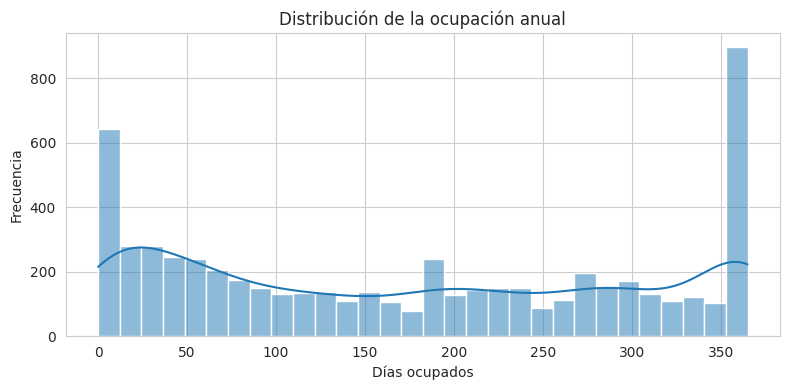

In [ ]:
# DISTRIBUCIÓN DE LA VARIABLE DEPENDIENTE
plt.figure(figsize=(8,4))

sns.histplot(
    data=df_modelo,
    x="occupancy_365",
    bins=30,
    kde=True
)

plt.title("Distribución de la ocupación anual")
plt.xlabel("Días ocupados")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Comentario:** este histograma muestra cómo se reparte la ocupación
anual entre los alojamientos. Si la distribución no es muy simétrica
(por ejemplo, si hay muchos alojamientos con pocos días ocupados y
pocos con muchos), conviene tenerlo presente al interpretar el
modelo, ya que la regresión lineal asume errores aproximadamente
normales, no que la variable dependiente en sí sea simétrica.

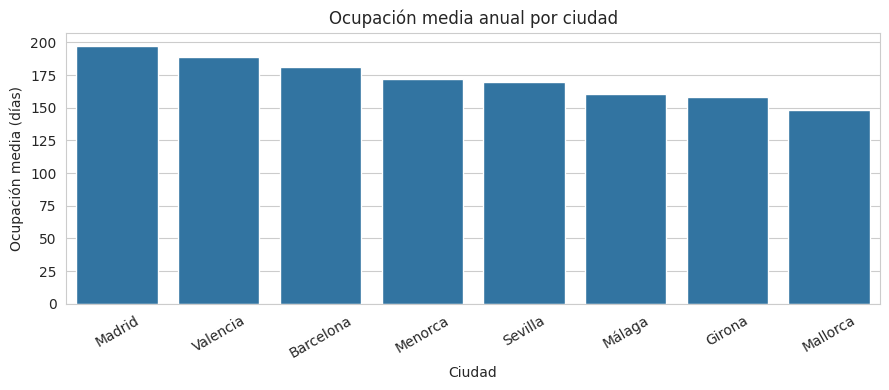

In [ ]:
# OCUPACIÓN MEDIA POR CIUDAD
ocupacion_ciudad = (
    df_modelo
    .groupby("city")["occupancy_365"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,4))

sns.barplot(
    x=ocupacion_ciudad.index,
    y=ocupacion_ciudad.values
)

plt.title("Ocupación media anual por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ocupación media (días)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Comentario:** este gráfico ordena las ciudades de mayor a menor
ocupación media. Es el primer indicio de si existen diferencias
relevantes entre ciudades, algo que después el modelo va a controlar
explícitamente mediante la variable `city`.

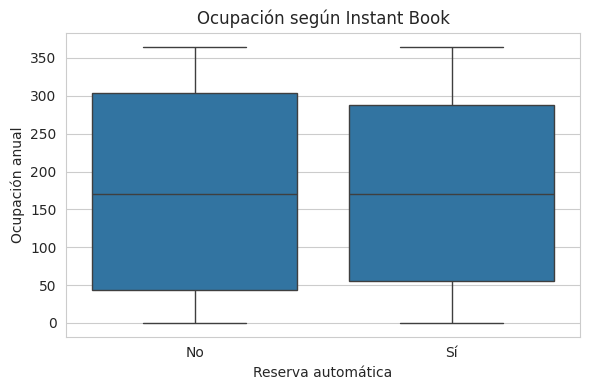

In [ ]:
# OCUPACIÓN SEGÚN RESERVA AUTOMÁTICA
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_modelo,
    x="is_instant_bookable_numeric",
    y="occupancy_365"
)

plt.xticks([0,1],["No","Sí"])

plt.xlabel("Reserva automática")
plt.ylabel("Ocupación anual")

plt.title("Ocupación según Instant Book")

plt.tight_layout()
plt.show()

**Comentario:** este boxplot compara la distribución de la ocupación
anual entre los alojamientos con reserva automática y los que no la
tienen. Es una primera aproximación visual a la pregunta de negocio,
antes de controlar por el resto de variables en el modelo.

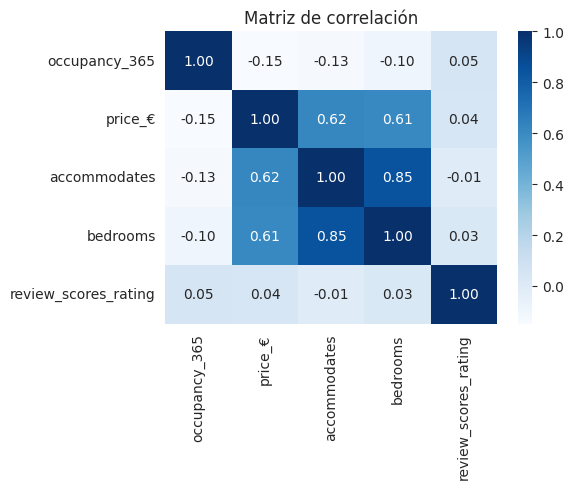

In [ ]:
# MATRIZ DE CORRELACIÓN
variables_corr = [
    "occupancy_365",
    "price_€",
    "accommodates",
    "bedrooms",
    "review_scores_rating"
]

corr = df_modelo[variables_corr].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

**Comentario:** la matriz de correlación permite detectar de un
vistazo relaciones lineales fuertes entre pares de variables
numéricas. Es un primer paso, complementario al VIF (sección 6),
que evalúa la multicolinealidad de forma conjunta y no solo por
parejas de variables.

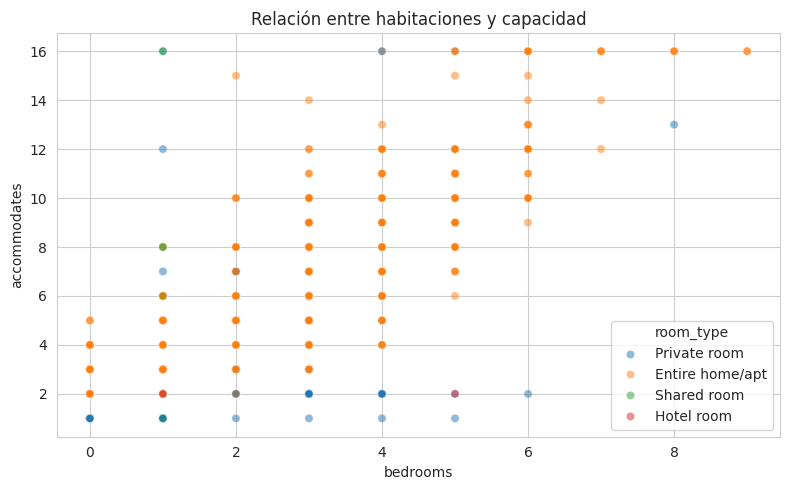

In [ ]:
# RELACIÓN ENTRE BEDROOMS Y ACCOMMODATES
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_modelo,
    x="bedrooms",
    y="accommodates",
    hue="room_type",
    alpha=0.5
)

plt.title("Relación entre habitaciones y capacidad")

plt.tight_layout()
plt.show()

**Comentario:** este gráfico de dispersión muestra que, como es
razonable, a más habitaciones suele haber más capacidad. Coloreando
por `room_type` se ve además que los alojamientos de tipo "Entire
home/apt" tienden a concentrar los valores más altos de ambas
variables, lo que es un indicio temprano de la posible
multicolinealidad que se revisa formalmente en la sección 5.

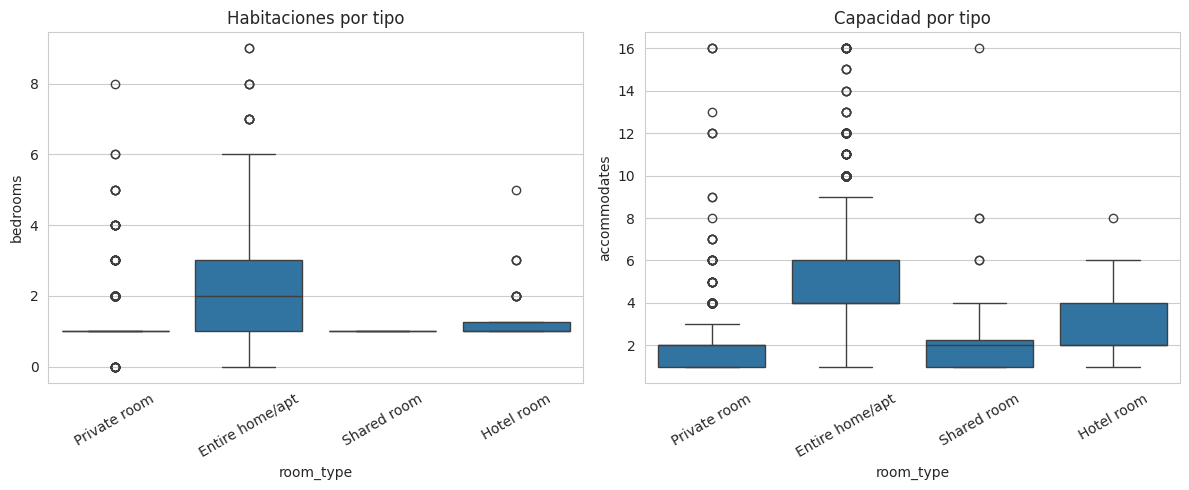

In [ ]:
# ROOM TYPE
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(
    data=df_modelo,
    x="room_type",
    y="bedrooms",
    ax=axes[0]
)

axes[0].set_title("Habitaciones por tipo")
axes[0].tick_params(axis="x",rotation=30)

sns.boxplot(
    data=df_modelo,
    x="room_type",
    y="accommodates",
    ax=axes[1]
)

axes[1].set_title("Capacidad por tipo")
axes[1].tick_params(axis="x",rotation=30)

plt.tight_layout()

plt.show()

**Comentario:** estos dos boxplots confirman que tanto el número de
habitaciones como la capacidad varían de forma sistemática según el
tipo de alojamiento, lo que refuerza la necesidad de comprobar la
multicolinealidad entre `bedrooms`, `accommodates` y `room_type`
antes de incluir las tres en el modelo.

/tmp/ipykernel_659/317856352.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


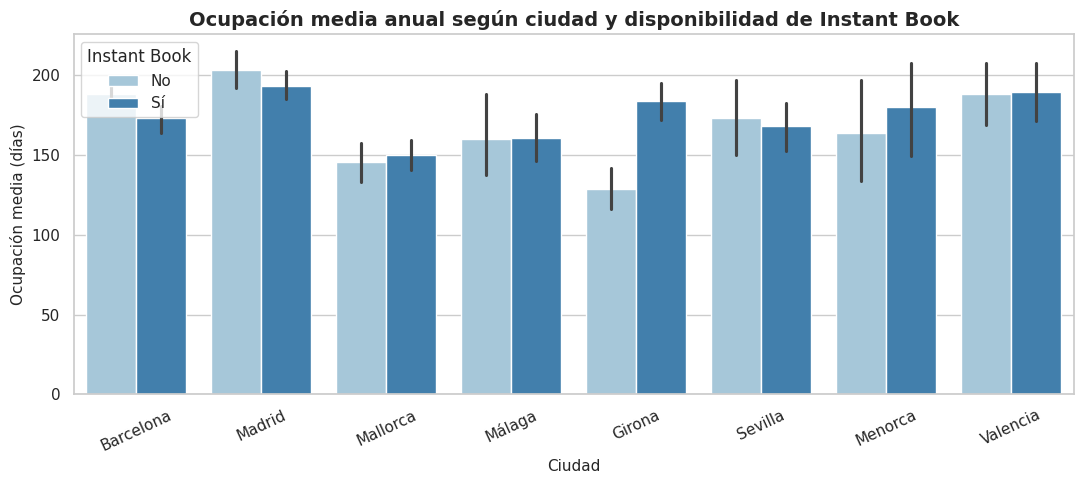

In [ ]:
# OCUPACIÓN MEDIA POR CIUDAD SEGÚN INSTANT BOOK
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=df_modelo,
    x="city",
    y="occupancy_365",
    hue="is_instant_bookable_numeric",
    estimator="mean",
    errorbar=("ci", 95),
    palette=["#9ecae1", "#3182bd"],
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ["No", "Sí"],
    title="Instant Book",
    frameon=True,
    loc="upper left"
)

ax.set_xticklabels(
    [c.title() for c in df_modelo["city"].unique()],
    rotation=25
)

ax.set_title(
    "Ocupación media anual según ciudad y disponibilidad de Instant Book",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Ciudad", fontsize=11)
ax.set_ylabel("Ocupación media (días)", fontsize=11)

plt.tight_layout()
plt.show()

**Comentario:** este gráfico cruza ciudad y reserva automática a la
vez, y es el más cercano a la pregunta de negocio: permite ver si la
diferencia de ocupación entre tener o no reserva automática se
mantiene igual en todas las ciudades, o si en algunas es mayor que
en otras. Los intervalos de confianza (barras de error) ayudan a
valorar si esas diferencias son visualmente relevantes o si podrían
deberse al azar.

### 4.1 Alojamientos con reserva automática por ciudad

Además de la ocupación media, es útil saber directamente **cuántos
alojamientos** de cada ciudad tienen activada la reserva automática,
en número absoluto. Esto ayuda a valorar, por ejemplo, si una
diferencia de ocupación observada en una ciudad se apoya en pocos
alojamientos o en muchos.

city
Barcelona    864
Madrid       776
Mallorca     483
Girona       425
Málaga       241
Sevilla      241
Valencia     167
Menorca       61
dtype: int64


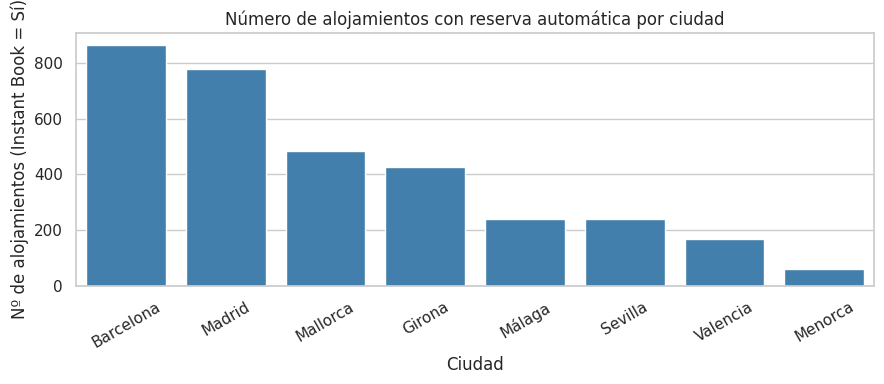

In [ ]:
# NÚMERO DE ALOJAMIENTOS CON INSTANT BOOK ACTIVO, POR CIUDAD
instant_book_ciudad = (
    df_modelo[df_modelo["is_instant_bookable_numeric"] == 1]
    .groupby("city")
    .size()
    .sort_values(ascending=False)
)

print(instant_book_ciudad)

plt.figure(figsize=(9, 4))

sns.barplot(
    x=instant_book_ciudad.index,
    y=instant_book_ciudad.values,
    color="#3182bd"
)

plt.title("Número de alojamientos con reserva automática por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Nº de alojamientos (Instant Book = Sí)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Comentario:** a diferencia del gráfico anterior (que muestra
medias y porcentajes), este gráfico da el número exacto de
alojamientos con reserva automática activa en cada ciudad. Es útil
como referencia de tamaño de muestra: una ciudad con pocos
alojamientos de este tipo tendrá una media de ocupación menos fiable
que una ciudad con muchos.

## 5. Revisión de multicolinealidad (exploración visual)

Antes de ajustar el modelo, conviene revisar si existe
multicolinealidad entre `bedrooms` (número de habitaciones),
`room_type` (tipo de alojamiento) y `accommodates` (capacidad), ya
que conceptualmente están muy relacionadas entre sí (un alojamiento
con más habitaciones suele tener más capacidad y suele ser del tipo
"Entire home/apt"). Se revisa esto **antes** de meter estas
variables en el modelo.

Correlación bedrooms vs accommodates: 0.85


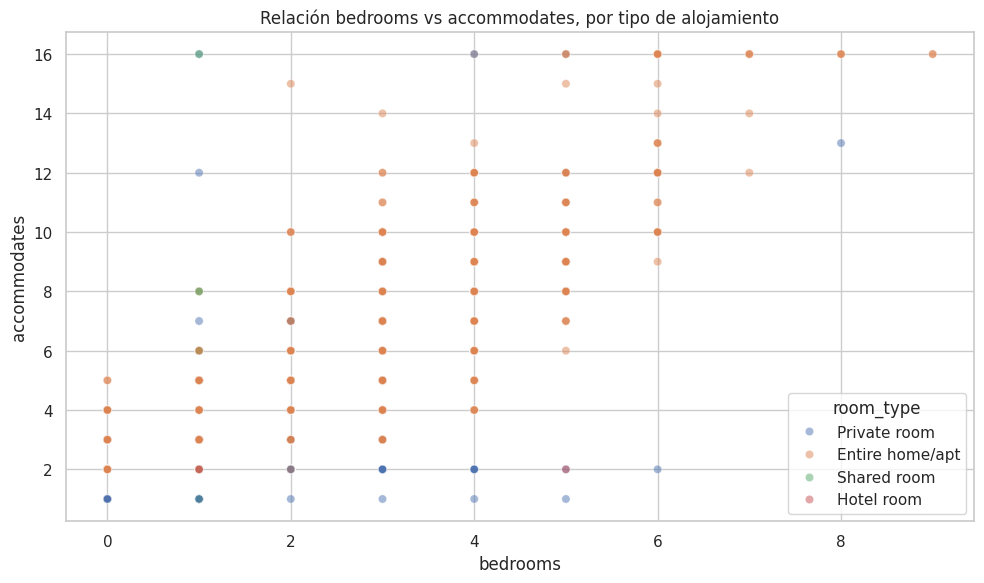

In [ ]:
# Correlación numérica directa entre bedrooms y accommodates
corr_bed_acc = df_modelo[['bedrooms', 'accommodates']].corr().iloc[0, 1]
print(f"Correlación bedrooms vs accommodates: {corr_bed_acc:.2f}")

fig, ax = plt.subplots()
sns.scatterplot(data=df_modelo, x='bedrooms', y='accommodates',
                 hue='room_type', alpha=0.5, ax=ax)
ax.set_title('Relación bedrooms vs accommodates, por tipo de alojamiento')
plt.tight_layout()
plt.show()

**Comentario:** la correlación entre `bedrooms` y `accommodates` es
positiva y notable, lo cual es esperable, pero por sí sola no basta
para decidir si hay que eliminar alguna variable: el VIF de la
sección 6 permite valorarlo de forma conjunta con todas las variables
del modelo a la vez.

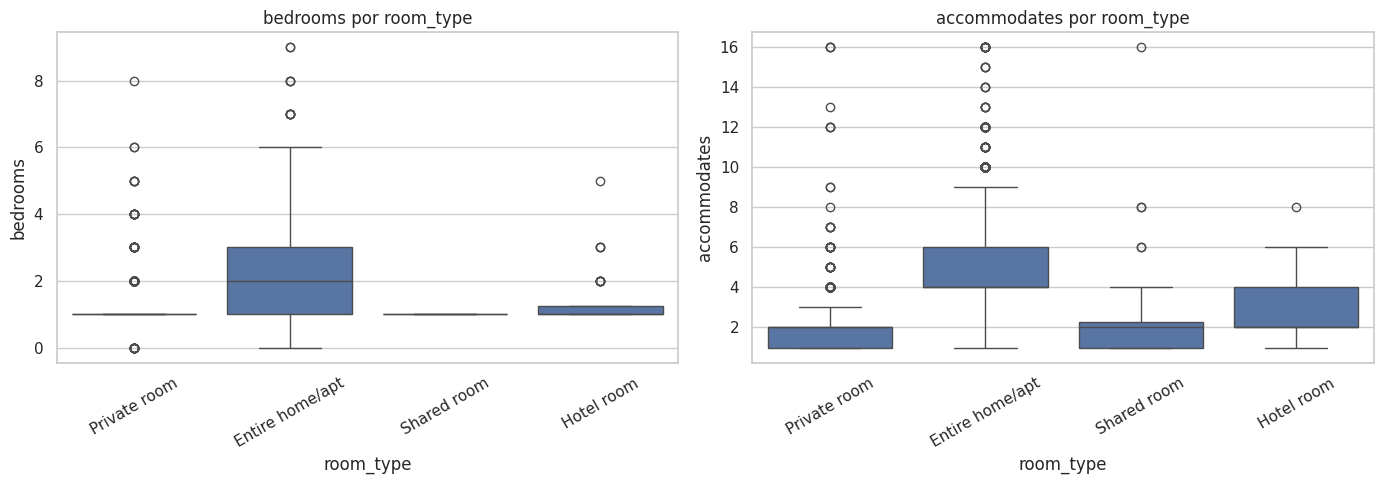

In [ ]:
# Relación entre room_type y las otras dos variables (vía boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_modelo, x='room_type', y='bedrooms', ax=axes[0])
axes[0].set_title('bedrooms por room_type')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_modelo, x='room_type', y='accommodates', ax=axes[1])
axes[1].set_title('accommodates por room_type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Comentario:** estos boxplots confirman visualmente que
`room_type` está asociado tanto a `bedrooms` como a `accommodates`.
Con esta base, pasamos al cálculo formal del VIF para decidir si
alguna de las tres variables debe eliminarse del modelo.

## 6. Comprobación de la multicolinealidad (VIF)

Antes de ajustar la regresión lineal múltiple, se evalúa la posible
existencia de multicolinealidad entre las variables explicativas
mediante el *Variance Inflation Factor* (VIF). Se construye la misma
matriz de diseño que utilizará después el modelo de regresión. Como
regla general, un VIF por encima de 5 se considera indicio de
multicolinealidad relevante y motivo para valorar eliminar esa
variable.

**Nota técnica:** la columna de precio se llama `price_€` en este
dataset. Como el símbolo `€` no es válido en un nombre de variable
de fórmula, se referencia como `Q('price_€')` en las fórmulas de
`patsy`/`statsmodels` (la función `Q()` permite usar como variable
cualquier nombre de columna, aunque no sea un identificador válido
de Python).

In [ ]:
# COMPROBACIÓN DE LA MULTICOLINEALIDAD

# Construimos la misma matriz de diseño que utilizará la regresión.
# Las variables categóricas se codifican automáticamente en variables dummy.

X = dmatrix(
    """
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    Q('price_€') +
    accommodates +
    bedrooms +
    review_scores_rating
    """,
    data=df_modelo,
    return_type="dataframe"
)

# Calculamos el VIF de cada variable explicativa
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif[vif["Variable"] != "Intercept"]
vif = vif.sort_values("VIF", ascending=False)

vif

,Variable,VIF
13,accommodates,4.708166
14,bedrooms,4.113849
12,Q('price_€'),1.823808
10,C(room_type)[T.Private room],1.710835
4,C(city)[T.Mallorca],1.484424
3,C(city)[T.Madrid],1.443096
2,C(city)[T.Girona],1.432612
6,C(city)[T.Málaga],1.193330
7,C(city)[T.Sevilla],1.181089
8,C(city)[T.Valencia],1.169953


**Interpretación y decisión sobre las dos variables con mayor VIF:**

Las dos variables con el VIF más alto son `accommodates` (≈4,71) y
`bedrooms` (≈4,11), justo las que el análisis visual de las
secciones 4 y 5 señalaba como candidatas a estar correlacionadas
entre sí. Sin embargo, **ninguna de las dos supera el umbral de 5**
que se suele usar como referencia para hablar de multicolinealidad
problemática.

Por eso, la decisión es **mantener ambas variables en el modelo**:
eliminar `accommodates` o `bedrooms` haría perder información de
control relevante (capacidad y número de habitaciones no son
intercambiables del todo, aunque estén relacionadas) sin que exista
una justificación estadística suficiente para retirarlas. El resto
de variables explicativas presentan valores de VIF claramente más
bajos, por lo que tampoco hay motivo para eliminarlas.

En resumen: existe cierta relación entre `accommodates` y
`bedrooms` (como cabía esperar), pero no lo bastante fuerte como
para distorsionar de forma relevante los coeficientes del modelo. Se
conservan todas las variables explicativas.

## 7. Reducción de datos

El dataset de partida (`df`) ya viene limpio y transformado, pero
sigue incluyendo muchas columnas que no se usan en este análisis
concreto: texto libre, identificadores, sub-puntuaciones de
valoración, fechas, y también variables de ingeniería de
características creadas para otras preguntas de negocio (categorías
de amenities, precio en logaritmo, umbral de valoración, etc.).
Siguiendo el principio de reducción de datos (quedarnos solo con lo
relevante para la pregunta de negocio), se descartan aquí las
columnas que con seguridad no se van a usar en esta regresión, para
dejar un dataframe más manejable de cara al resto del proyecto.

**Columnas que se eliminan y motivo:**

| Columna | Motivo |
|---|---|
| `name`, `description`, `amenities_list` | Texto libre, no se usa en el modelo |
| `host_id` | Identificador del anfitrión, no es una variable de control en este análisis |
| `neighbourhood_name`, `neighbourhood_district` | Ya se controla por `city`, no se baja a nivel de barrio |
| `bathrooms`, `beds` | No forman parte de las variables de control seleccionadas |
| `minimum_nights`, `maximum_nights`, `has_availability`, `has_availability_numeric` | No se usan en este modelo |
| `number_of_reviews`, `first_review_date`, `last_review_date`, `reviews_per_month` | No se usan en este modelo (solo se usa `review_scores_rating`) |
| `review_scores_accuracy`, `review_scores_cleanliness`, `review_scores_checkin`, `review_scores_communication`, `review_scores_location`, `review_scores_value` | Sub-puntuaciones no usadas; solo se conserva la puntuación general |
| `rating_above_80` | Variable de umbral de valoración creada para otra pregunta de negocio, no se usa aquí |
| `country`, `insert_date` | Metadatos sin relevancia para este modelo |
| `is_instant_bookable` | Se sustituye por su versión numérica (`is_instant_bookable_numeric`) |
| `occupancy_rate_30/60/90/365` | Versión en porcentaje; el modelo trabaja con ocupación en días |
| `cat_premium`, `cat_confort`, `cat_conectividad`, `cat_familia`, `cat_seguridad`, `cat_parking`, `cat_cocina` | Categorías de amenities creadas para otro análisis, no forman parte de este modelo |
| `logp` | Transformación logarítmica del precio, no se usa aquí (el modelo trabaja con `price_€` en su escala original) |

Se conservan `apartment_id` (identificador del alojamiento, útil
para trazabilidad) y todas las variables usadas en el modelo y en
la comprobación de robustez.

In [ ]:
columnas_a_eliminar = [
    'name', 'description', 'amenities_list',
    'host_id',
    'neighbourhood_name', 'neighbourhood_district',
    'bathrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'has_availability',
    'has_availability_numeric',
    'number_of_reviews', 'first_review_date', 'last_review_date',
    'reviews_per_month',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'rating_above_80',
    'country', 'insert_date',
    'is_instant_bookable',
    'occupancy_rate_30', 'occupancy_rate_60',
    'occupancy_rate_90', 'occupancy_rate_365',
    'cat_premium', 'cat_confort', 'cat_conectividad',
    'cat_familia', 'cat_seguridad', 'cat_parking', 'cat_cocina',
    'logp'
]

df_reducido = df.drop(columns=columnas_a_eliminar)

print("Columnas antes de la reducción:", df.shape[1])
print("Columnas después de la reducción:", df_reducido.shape[1])
df_reducido.head()

Columnas antes de la reducción: 54
Columnas después de la reducción: 16


,apartment_id,room_type,accommodates,bedrooms,price_€,availability_30,availability_60,availability_90,availability_365,review_scores_rating,city,occupancy_30,occupancy_60,occupancy_90,occupancy_365,is_instant_bookable_numeric
0,15695052,Private room,1,1.0,350.0,29,59,89,364,NaN,Barcelona,1,1,1,1,1
1,14999488,Private room,2,1.0,250.0,4,18,48,104,90.0,Barcelona,26,42,42,261,1
2,12265320,Private room,2,1.0,650.0,30,60,90,365,99.0,Barcelona,0,0,0,0,0
3,16272738,Private room,2,1.0,760.0,27,55,85,360,100.0,Barcelona,3,5,5,5,1
4,16262996,Private room,2,1.0,350.0,27,54,84,85,NaN,Barcelona,3,6,6,280,0


**Comentario:** `df_reducido` es el dataframe recomendado para
continuar el proyecto en esta línea de análisis (ocupación /
reserva automática). No sustituye a `df_modelo` (que además ya tiene
los nulos eliminados y solo las columnas estrictas del modelo), sino
que sirve como versión intermedia, más limpia que el dataset bruto,
por si se necesitan variables adicionales (como `apartment_id`) en
pasos posteriores.

## 8. Modelo final y resultados

Ajustamos la regresión lineal múltiple con `occupancy_365` como
variable dependiente. Las variables categóricas (`city`, `room_type`
e `is_instant_bookable_numeric`) se incorporan al modelo mediante
`C()`; la API de fórmulas de `statsmodels` realiza automáticamente
la codificación en variables dummy y selecciona una categoría de
referencia para cada variable.

In [ ]:
modelo = smf.ols(
    """
    occupancy_365 ~
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    Q('price_€') +
    accommodates +
    bedrooms +
    review_scores_rating
    """,
    data=df_modelo
).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          occupancy_365   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     17.26
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           2.12e-45
Time:                        12:47:59   Log-Likelihood:                -37119.
No. Observations:                5936   AIC:                         7.427e+04
Df Residuals:                    5920   BIC:                         7.438e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                             119.2650     17.783      6.707      0.000      84.404     154.126
C(is_instant_bookable_numeric)[T.1]     6.8710      3.363      2.043      0.041       0.278      13.464
C(city)[T.Girona]                      -9.6462      5.753     -1.677      0.094     -20.923       1.631
C(city)[T.Madrid]                      18.5290      4.685      3.955      0.000       9.345      27.713
C(city)[T.Mallorca]                   -18.7725      5.756     -3.261      0.001     -30.056      -7.489
C(city)[T.Menorca]                      5.5730     11.993      0.465      0.642     -17.937      29.083
C(city)[T.Málaga]                     -16.5437      7.620     -2.171      0.030     -31.481      -1.606
C(city)[T.Sevilla]                     -5.8078      7.431     -0.782      0.435     -20.376       8.761
C(city)[T.Valencia]                     9.5710      7.715      1.241      0.215      -5.552      24.694
C(room_type)[T.Hotel room]              1.7539     20.142      0.087      0.931     -37.732      41.240
C(room_type)[T.Private room]           18.2350      4.736      3.850      0.000       8.951      27.519
C(room_type)[T.Shared room]           -49.3865     21.232     -2.326      0.020     -91.009      -7.764
Q('price_€')                           -0.0176      0.003     -6.357      0.000      -0.023      -0.012
accommodates                           -4.4784      1.471     -3.045      0.002      -7.361      -1.596
bedrooms                               10.6329      2.847      3.735      0.000       5.052      16.214
review_scores_rating                    0.6901      0.184      3.742      0.000       0.329       1.052
==============================================================================
Omnibus:                    25157.559   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              429.370
Skew:                           0.080   Prob(JB):                     5.80e-94
Kurtosis:                       1.692   Cond. No.                     1.62e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.62e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretación de los resultados:**

El modelo de regresión lineal múltiple resultó significativo en su
conjunto (F = 17,26; p < 0,001), lo que indica que las variables
incluidas aportan información para explicar la ocupación anual de
los alojamientos, sobre una muestra de 5.936 registros (tras
eliminar nulos). Aunque el poder explicativo del modelo es limitado
(R² ajustado = 0,039), los resultados muestran que la reserva
automática (Instant Book) tiene un efecto positivo y
estadísticamente significativo sobre la ocupación (coeficiente =
6,87; p = 0,041). En concreto, los alojamientos con reserva
automática presentan, en promedio, casi 7 días más de ocupación al
año que aquellos que requieren aprobación del propietario,
manteniendo constantes la ciudad, el tipo de alojamiento, el precio,
la capacidad, el número de habitaciones y la valoración.

Sobre el resto de variables de control: el número de habitaciones
(`bedrooms`, +10,63) y la valoración (`review_scores_rating`, +0,69)
muestran una asociación positiva con la ocupación, mientras que el
precio (`price_€`, −0,018) y la capacidad (`accommodates`, −4,48)
presentan una asociación negativa. También hay diferencias notables
entre ciudades: Madrid (+18,53) y las habitaciones privadas
(`Private room`, +18,24) destacan con coeficientes positivos y
significativos, mientras que Mallorca (−18,77) y Málaga (−16,54)
muestran coeficientes negativos y significativos frente a la ciudad
de referencia.

Aunque el resumen del modelo muestra un número de condición
elevado, el análisis mediante VIF (sección 6) no detectó
multicolinealidad relevante entre las variables explicativas.

## 9. Verificación de supuestos del modelo

Quedan dos supuestos por verificar: la **normalidad de los
residuos** y la **homocedasticidad** (la multicolinealidad ya se
resolvió en la sección 6 con el VIF).

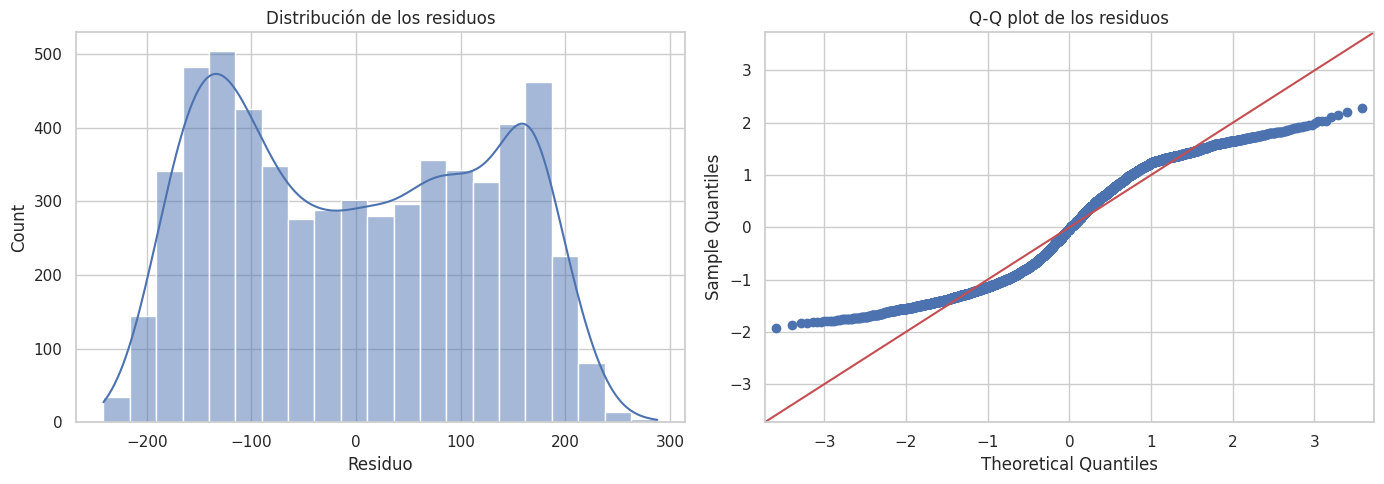

In [ ]:
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residuo')

sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')

plt.tight_layout()
plt.savefig('../Results/residuos_modelo_ocupacion.png', dpi=150,
            bbox_inches='tight')
plt.show()

**Comentario:** el histograma de la izquierda muestra la forma de
la distribución de los residuos, y el Q-Q plot de la derecha compara
esa distribución con una normal teórica (los puntos deberían seguir
la línea diagonal si los residuos fueran normales). Cuanto más se
alejen los puntos de la diagonal en los extremos, más se aleja la
distribución real de la normalidad.

In [ ]:
# Test de Jarque-Bera para normalidad de los residuos
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuos)
print(f"Jarque-Bera: estadístico={jb_stat:.2f}, p-valor={jb_pvalue:.4f}")
print("H0: los residuos siguen una distribución normal.")
print("Si p-valor < 0.05, se rechaza la normalidad de los residuos.")

Jarque-Bera: estadístico=429.37, p-valor=0.0000
H0: los residuos siguen una distribución normal.
Si p-valor < 0.05, se rechaza la normalidad de los residuos.


**Comentario:** el test de Jarque-Bera da un estadístico de 429,37
con un p-valor prácticamente cero (5,8e-94), muy por debajo de 0,05.
Esto confirma de forma numérica lo que ya se intuía en el histograma
y el Q-Q plot: los residuos **no siguen una distribución normal**.
Esto no invalida el modelo (los coeficientes siguen siendo
interpretables), pero sí obliga a interpretar los p-valores con
cierta prudencia, especialmente en variables cuyo p-valor está cerca
del umbral de 0,05 (como es el caso de `is_instant_bookable_numeric`
en el modelo de 365 días).

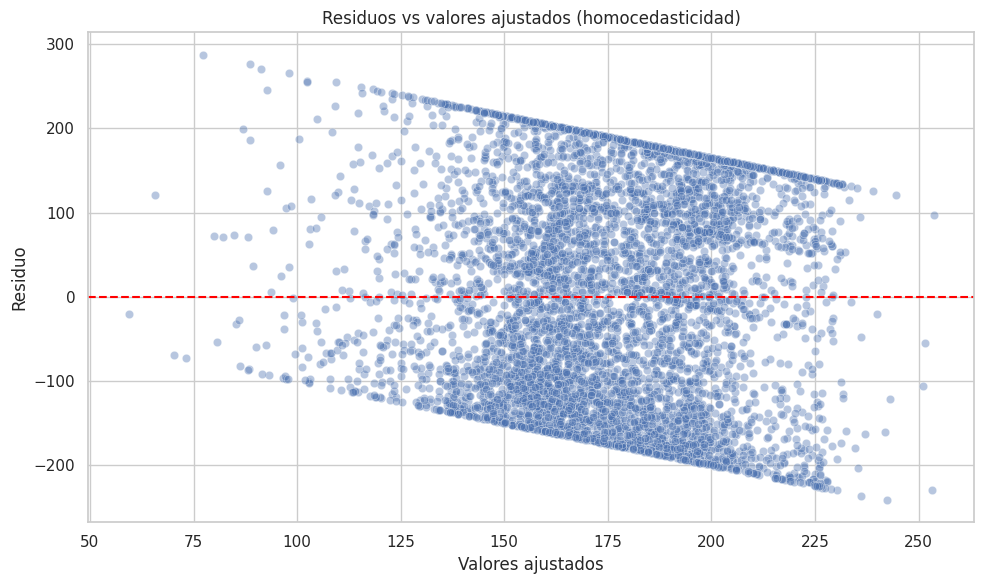

In [ ]:
# Homocedasticidad: residuos vs valores ajustados
fig, ax = plt.subplots()
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.4, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuos vs valores ajustados (homocedasticidad)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuo')
plt.tight_layout()
plt.show()

**Cómo interpretar esta sección:** una nube de puntos sin forma de
embudo alrededor del cero indica homocedasticidad razonable; un
histograma de residuos con forma de campana y puntos alineados en el
Q-Q plot apoyan la normalidad. Si estos supuestos no se cumplen bien,
los p-valores del modelo deben interpretarse con cautela (no
invalidan el modelo, pero piden prudencia en las conclusiones).

## 10. Robustez: repetir el modelo a 30, 60, 90 y 365 días

Repetimos el mismo modelo cambiando únicamente la variable
dependiente, para ver si el efecto de la reserva automática es
estable en los cuatro plazos disponibles (30, 60, 90 y 365 días) o
si cambia según el horizonte temporal.

In [ ]:
import statsmodels.formula.api as smf

# Variables dependientes que queremos comparar (los 4 plazos disponibles)
horizontes = [
    "occupancy_30",
    "occupancy_60",
    "occupancy_90",
    "occupancy_365"]

resultados = []

for y in horizontes:

    formula = f"""
    {y} ~
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    Q('price_€') +
    accommodates +
    bedrooms +
    review_scores_rating
    """

    modelo_horizonte = smf.ols(
        formula=formula,
        data=df_modelo).fit()

    resultados.append({
        "Horizonte": y,
        "Coeficiente Instant Book": round(
            modelo_horizonte.params["C(is_instant_bookable_numeric)[T.1]"], 2
        ),
        "p-valor": round(
            modelo_horizonte.pvalues["C(is_instant_bookable_numeric)[T.1]"], 4
        ),
        "R² ajustado": round(
            modelo_horizonte.rsquared_adj, 3
        )})

resultados_robustez = pd.DataFrame(resultados)

resultados_robustez

,Horizonte,Coeficiente Instant Book,p-valor,R² ajustado
0,occupancy_30,0.43,0.1539,0.028
1,occupancy_60,0.33,0.5728,0.021
2,occupancy_90,0.23,0.7911,0.018
3,occupancy_365,6.87,0.0411,0.039


**Comentario:** esta tabla permite comparar, de un vistazo, si el
efecto de la reserva automática (coeficiente, significancia y R²
ajustado) se mantiene estable entre los cuatro plazos disponibles o
si varía de forma relevante. Con los datos actuales, el coeficiente
es pequeño y no significativo a 30 días (+0,43; p = 0,154), a 60
días (+0,33; p = 0,573) y a 90 días (+0,23; p = 0,791), pero se
vuelve claramente mayor y significativo a 365 días (+6,87; p =
0,041). Esto sugiere que el efecto de la reserva automática sobre la
ocupación se nota sobre todo en el largo plazo, y que a corto plazo
la diferencia entre tener o no reserva automática no se distingue
del azar.

## 11. Conclusiones y propuestas

**Conclusiones a partir del modelo:**
- El coeficiente de `is_instant_bookable_numeric` en el modelo de
  365 días es positivo (+6,87 días de ocupación) y estadísticamente
  significativo, aunque de forma ajustada (p = 0,041, justo por
  debajo de 0,05).
- El efecto no es estable entre plazos: es pequeño y no significativo
  a 30, 60 y 90 días, y solo se hace claramente mayor y significativo
  a 365 días (sección 10).
- Los supuestos de normalidad de los residuos no se cumplen
  (test de Jarque-Bera, sección 9: p ≈ 0), por lo que los p-valores
  deben interpretarse con cierta prudencia, en especial el de
  `is_instant_bookable_numeric`, que está cerca del umbral de 0,05;
  la homocedasticidad, revisada visualmente, es razonable.
- El modelo muestra una **correlación controlada**, no una relación
  de causalidad, y su capacidad explicativa es limitada (R² ajustado
  = 0,039, sobre 5.936 registros tras eliminar nulos): hay otros
  factores fuera del modelo que también influyen en la ocupación.

**Propuestas de negocio:**
- Dado que el efecto es positivo y significativo a 365 días, aunque
  moderado, se puede valorar incentivar o comunicar activamente la
  opción de reserva automática a los anfitriones, sobre todo en
  ciudades como Mallorca y Málaga, donde el modelo muestra una
  ocupación media más baja (sección 4 y sección 8).
- Como el efecto es débil y no significativo en plazos cortos, no
  conviene basar campañas o mensajes de corto plazo únicamente en la
  reserva automática; conviene combinarlo con otras palancas (precio,
  valoración, tipo de alojamiento).
- Dado que el p-valor del coeficiente de interés está cerca del
  límite de significancia (0,041) y los residuos no son
  perfectamente normales, se recomienda tratar este resultado como
  un indicio a confirmar, no como una conclusión cerrada.
- En cualquier caso, el resultado debe comunicarse como una
  asociación controlada por otros factores, no como una relación de
  causa-efecto, para evitar decisiones operativas basadas en una
  lectura simplificada del dato.

**Limitaciones y próximos pasos:**
- Al eliminar nulos en `price_€`, `bedrooms` y, sobre todo, en
  `review_scores_rating` (esta última con 1.634 valores nulos), la
  muestra se reduce de 7.693 a 5.936 registros; conviene valorar si
  esa pérdida de datos afecta a las conclusiones (por ejemplo,
  comprobando si los alojamientos sin valoración se concentran en
  algún tipo de alojamiento o ciudad).
- No se incluyen variables como el tipo de anfitrión, que podrían
  explicar parte de la ocupación y no están en este modelo.
- Se recomienda validar los resultados con el resto del equipo antes
  de trasladarlos a Power BI o a la documentación final.

## 12. Resumen de cambios respecto al notebook anterior

Este notebook (`data_transform_06_07_2026.ipynb`) parte del notebook
de análisis de reserva automática y ocupación, y añade lo siguiente:

- **Markdown revisado en todo el notebook**, con explicaciones
  cortas y claras de qué hace cada bloque de código, pensadas para
  que cualquier persona del equipo pueda seguir el notebook sin
  contexto previo.
- **Referencias personales eliminadas**: ya no se menciona a ninguna
  persona del equipo por su nombre; las decisiones metodológicas se
  explican por su justificación, no por quién las propuso.
- **Comentario e interpretación añadidos a todos los gráficos** de
  la sección de EDA, la revisión de multicolinealidad y la
  verificación de supuestos (antes varios gráficos no tenían ninguna
  explicación posterior).
- **Nuevo gráfico y código (sección 4.1)**: número exacto de
  alojamientos con reserva automática activa, por ciudad, como
  complemento a los gráficos de medias y porcentajes que ya existían.
- **Interpretación explícita del VIF (sección 6)**: se valora de
  forma directa si conviene eliminar `accommodates` y `bedrooms`
  (las dos variables con mayor VIF) y se justifica por qué se
  mantienen ambas en el modelo.
- **Nueva sección de reducción de datos (sección 7)**: se elimina de
  forma explícita el conjunto de columnas del dataset bruto que no
  se usan en este análisis, con una tabla que documenta el motivo de
  cada eliminación, y se genera `df_reducido` como dataframe de
  referencia para el resto del proyecto.
- **Nombre y ruta del notebook actualizados** a
  `data_transform_06_07_2026.ipynb`, siguiendo la convención de
  nombres del equipo (`DD_MM_YYYY`).
- **Dataset actualizado a `clean_dataset_06_07_2026.csv`**: este
  archivo ya llega limpio y transformado, con las columnas de
  ocupación y `is_instant_bookable_numeric` ya calculadas; las
  secciones 2.1 y 2.2 se han adaptado para funcionar como
  verificación de esos valores en lugar de creación desde cero.
- **Columna de precio renombrada de `price` a `price_€`**, reflejando
  el nombre real en el nuevo dataset; en las fórmulas de
  `patsy`/`statsmodels` se usa `Q('price_€')`, ya que el símbolo `€`
  no es un carácter válido en un nombre de variable de fórmula.
- **Reducción de datos actualizada (sección 7)**: se añaden a la
  lista de columnas eliminadas las variables de ingeniería de
  características que ya vienen en este dataset y no se usan en este
  análisis (`cat_premium`, `cat_confort`, `cat_conectividad`,
  `cat_familia`, `cat_seguridad`, `cat_parking`, `cat_cocina`,
  `logp`, `rating_above_80`, `has_availability_numeric`).
- **Resultados numéricos recalculados con los datos reales**: VIF,
  coeficientes del modelo, p-valores, test de Jarque-Bera y tabla de
  robustez (secciones 6, 8, 9, 10 y 11) reflejan ahora los valores
  obtenidos con `clean_dataset_06_07_2026.csv` (muestra final de
  5.936 registros tras eliminar nulos), y ya no las cifras del
  notebook anterior.

Lo que se mantiene igual: la lógica de carga de datos, la
construcción de las variables de ocupación, la selección de
variables del modelo, la estructura del modelo de regresión final y
la comprobación de robustez en los cuatro plazos.